# **Day 88: Geospatial ML Methodology: Spatial Cross-Validation, Area of Applicability and Accuracy Assessment**
*Module 13 - Remote Sensing ML and Publication Projects*

Reviewers of remote-sensing papers reject more manuscripts for **flawed validation** than for weak models. Pixels are not independent: neighbouring pixels look alike (*spatial autocorrelation*), training data are usually *clustered* (field campaigns follow roads; analysts digitise polygons), and the map is applied to places the model never saw. A random train/test split then measures how well the model **interpolates between near-duplicates**, not how accurate the **map** is.

Because our study area is simulated, we know the true land cover for every pixel. So we can do what is impossible in real life: compare every validation strategy against the **true map accuracy**.

> Nearby pixels look alike, so randomly splitting pixels into training and test sets overestimates accuracy. Spatial cross-validation keeps test areas away from training areas, and a proper probability sample gives honest map accuracy and area estimates.
>
> *Example:* If test pixels sit 20 m from training pixels in the same field, the model is tested on near-copies. Testing on fields 5 km away is a fair test.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio, time
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.metrics import accuracy_score
import rs_utils as ru
DATA = Path("data/study_area")
rng = np.random.default_rng(1)

with rasterio.open(DATA / "feature_stack_2024.tif") as src:
    stack = src.read(); names = list(src.descriptions); T = src.transform
with rasterio.open(DATA / "terrain.tif") as src:
    terrain = src.read(); terrain_names = list(src.descriptions)
truth = rasterio.open(DATA / "_truth_landcover_SIMULATION_ONLY.tif").read(1)   # unknown in real life
H, W = truth.shape
X_all = stack.reshape(len(names), -1).T
print(f"{len(names)} features, {H}x{W} pixels, cloud-gap NaNs: {np.isnan(X_all).mean():.3%}")
X_all = np.where(np.isnan(X_all), np.nanmedian(X_all, 0), X_all)            # simple gap filling (state it in the paper)
y_all = truth.ravel()
rows_all, cols_all = np.divmod(np.arange(H * W), W)
x_all, yc_all = ru.pixel_centres(T, rows_all, cols_all)
PIXEL_HA = 20 * 20 / 1e4
rf = lambda n=200: RandomForestClassifier(n, n_jobs=-1, random_state=0)

67 features, 500x500 pixels, cloud-gap NaNs: 1.067%


## **1. Why Validation in Remote Sensing Is Different**
Three facts break the i.i.d. assumption behind a random split:

| Fact | Consequence |
|---|---|
| **Spatial autocorrelation**: nearby pixels share land cover, soil, illumination, haze | A test pixel 20 m from a training pixel is almost a copy of it |
| **Clustered training data**: polygons digitised on imagery, field plots along roads | Random CV puts pixels of the *same polygon* in train and test |
| **Prediction is wall-to-wall**: the map covers places far (in space and in feature space) from any training sample | Accuracy near the samples is higher than accuracy across the map |

What the paper needs is the **accuracy of the map**: the proportion of the mapped area that is correctly classified. Only a **probability sample** of reference data, analysed with design-based estimators, estimates it without bias (Stehman & Foody 2019). Cross-validation is for **model development**: choosing features, models and hyperparameters. The rest of today makes both precise.

## **2. Measuring Spatial Autocorrelation**
**Moran's I** compares each value with its neighbours' values: +1 means neighbours are alike, 0 means no spatial pattern. The **semivariogram** gamma(h) = 1/2 E[(z(s) - z(s+h))^2] shows how dissimilarity grows with distance h. It flattens at the **sill**, and the distance where it flattens is the **range**: beyond the range, observations are practically independent.

Moran's I of monsoon NDVI at 600 random points (k = 8 neighbours): 0.456


permutation null: mean -0.004, 97.5th percentile 0.035


exponential variogram: nugget 0.0047, partial sill 0.0229, practical range 2036 m


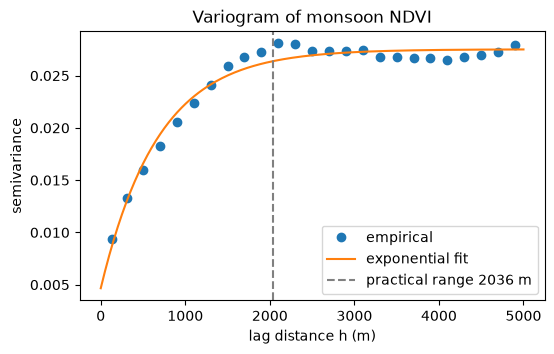

In [2]:
ndvi = X_all[:, names.index("monsoon_NDVI")]                                  # gap-filled
srs = rng.choice(H * W, 600, replace=False)                                   # a simple random sample of 600 pixels
print(f"Moran's I of monsoon NDVI at 600 random points (k = 8 neighbours): {ru.morans_i(ndvi[srs], x_all[srs], yc_all[srs]):.3f}")
perm = [ru.morans_i(rng.permutation(ndvi[srs]), x_all[srs], yc_all[srs]) for _ in range(199)]
print(f"permutation null: mean {np.mean(perm):.3f}, 97.5th percentile {np.percentile(perm, 97.5):.3f}")

def empirical_variogram(z, x, y, max_lag=5000, n_bins=25, n_pts=3000, seed=0):
    i = np.random.default_rng(seed).choice(len(z), n_pts, replace=False)
    d = pdist(np.c_[x[i], y[i]]); g = 0.5 * pdist(z[i][:, None], "sqeuclidean")
    k = np.digitize(d, np.linspace(0, max_lag, n_bins + 1)) - 1; ok = k < n_bins
    cnt = np.bincount(k[ok], minlength=n_bins)
    return np.bincount(k[ok], d[ok], n_bins) / cnt, np.bincount(k[ok], g[ok], n_bins) / cnt

exp_model = lambda h, nugget, psill, a: nugget + psill * (1 - np.exp(-h / a))
lag, gam = empirical_variogram(ndvi, x_all, yc_all)
(c0, c1, a), _ = curve_fit(exp_model, lag, gam, p0=[0.001, gam.max(), 500], bounds=(0, np.inf))
practical_range = 3 * a                                                         # distance at 95% of the sill
print(f"exponential variogram: nugget {c0:.4f}, partial sill {c1:.4f}, practical range {practical_range:.0f} m")
hh = np.linspace(0, 5000, 200)
plt.figure(figsize=(6, 3.5)); plt.plot(lag, gam, "o", label="empirical"); plt.plot(hh, exp_model(hh, c0, c1, a), label="exponential fit")
plt.axvline(practical_range, ls="--", c="gray", label=f"practical range {practical_range:.0f} m")
plt.xlabel("lag distance h (m)"); plt.ylabel("semivariance"); plt.title("Variogram of monsoon NDVI"); plt.legend(); plt.show()

The positive Moran's I lies far outside the permutation null, so NDVI is strongly autocorrelated. The variogram gives a scale: samples closer than about the practical range carry overlapping information. We use this distance to size the spatial CV blocks and buffers below.

## **3. Two Training Designs**
- **Design A: simple random sample (SRS)** of 600 pixels across the whole area. It is statistically ideal but expensive in the field.
- **Design B: polygon-clustered sample**: 40 "training polygons" digitised by an analyst within 600 m of a road, with 15 pixels taken from each. This is how most real training sets are built.

                      water  forest  cropland  built_up  mining_bare  \
A: random (SRS)           7     213        98        10           21   
B: polygon-clustered      1     200        72        69            4   

                      shrub_grass  
A: random (SRS)               251  
B: polygon-clustered          254  


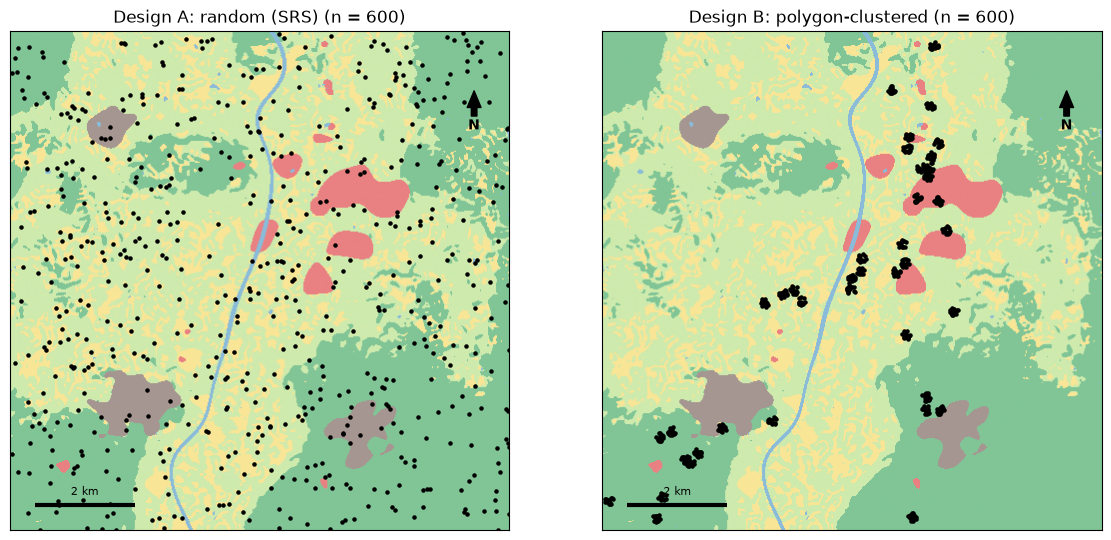

In [3]:
dist_road = terrain[terrain_names.index("dist_road_m")].ravel()
centres = rng.choice(np.flatnonzero(dist_road < 600), 40, replace=False)
clu, poly_id = [], []
for k, c in enumerate(centres):
    r0, c0_ = divmod(c, W)
    pool = np.flatnonzero(np.hypot(rows_all - r0, cols_all - c0_) < 5)        # a ~100 m polygon
    clu += list(rng.choice(pool, 15, replace=False)); poly_id += [k] * 15
clu, poly_id = np.array(clu), np.array(poly_id)
designs = {"A: random (SRS)": srs, "B: polygon-clustered": clu}
print(pd.DataFrame({d: np.bincount(y_all[i], minlength=6) for d, i in designs.items()}, index=ru.LC_CLASSES).T)

cmap, norm = ru.categorical_cmap(); ext = ru.map_extent(T, truth.shape)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, (d, i) in zip(axes, designs.items()):
    ax.imshow(truth, cmap=cmap, norm=norm, extent=ext, alpha=0.55)
    ax.scatter(x_all[i], yc_all[i], c="k", s=5); ax.set_title(f"Design {d} (n = {len(i)})")
    ru.add_scalebar(ax, 2000, ext); ru.add_north_arrow(ax); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Design B already reveals one problem: some classes (water, mining) are rare or absent near roads, so the model cannot learn them. **No cross-validation can detect errors on classes or places that were never sampled.**

## **4. Cross-Validation Strategies vs the True Map Accuracy**
| Strategy | How test folds are formed | Mimics |
|---|---|---|
| Random k-fold | random pixels | interpolation between samples |
| Spatial block | square blocks of side >= range, `GroupKFold` | prediction into new areas |
| Leave-polygon-out | all pixels of a polygon together | new polygons |
| Buffered LOO | one test point; training excludes points within a buffer | prediction at a distance >= buffer |

In [4]:
BLOCK = float(np.clip(np.ceil(practical_range / 500) * 500, 1000, 3000))     # block side from the variogram
BUFFER = float(np.clip(practical_range, 500, 2000))
print(f"block size {BLOCK:.0f} m, LOO buffer {BUFFER:.0f} m")

def cv_accuracy(idx, groups=None, strategy="random", model=None):
    X, y = X_all[idx], y_all[idx]; model = model or rf()
    if strategy == "random":
        return accuracy_score(y, cross_val_predict(model, X, y, cv=KFold(5, shuffle=True, random_state=0)))
    if strategy in ("block", "polygon"):
        return accuracy_score(y, cross_val_predict(model, X, y, cv=GroupKFold(5), groups=groups))
    if strategy == "buffered_loo":
        hits = []
        for tr, te in ru.buffered_loo_splits(x_all[idx], yc_all[idx], BUFFER, max_tests=150, seed=0):
            hits.append(rf(100).fit(X[tr], y[tr]).predict(X[te])[0] == y[te][0])
        return np.mean(hits)

rows_out, maps = [], {}
for d, idx in designs.items():
    t0 = time.perf_counter()
    model = rf().fit(X_all[idx], y_all[idx]); maps[d] = model.predict(X_all).reshape(H, W)
    res = {"design": d, "TRUE map accuracy": accuracy_score(y_all, maps[d].ravel()),
           "random 5-fold": cv_accuracy(idx), "spatial block": cv_accuracy(idx, ru.spatial_blocks(x_all[idx], yc_all[idx], BLOCK), "block"),
           "buffered LOO": cv_accuracy(idx, strategy="buffered_loo")}
    if d.startswith("B"): res["leave-polygon-out"] = cv_accuracy(idx, poly_id, "polygon")
    rows_out.append(res); print(f"{d}: done in {time.perf_counter() - t0:.0f}s")
cv_table = pd.DataFrame(rows_out).set_index("design")
cv_table.round(3)

block size 2500 m, LOO buffer 2000 m


A: random (SRS): done in 23s


B: polygon-clustered: done in 22s


,TRUE map accuracy,random 5-fold,spatial block,buffered LOO,leave-polygon-out
design,,,,,
A: random (SRS),0.948,0.948,0.942,0.893,NaN
B: polygon-clustered,0.919,0.972,0.957,0.873,0.938


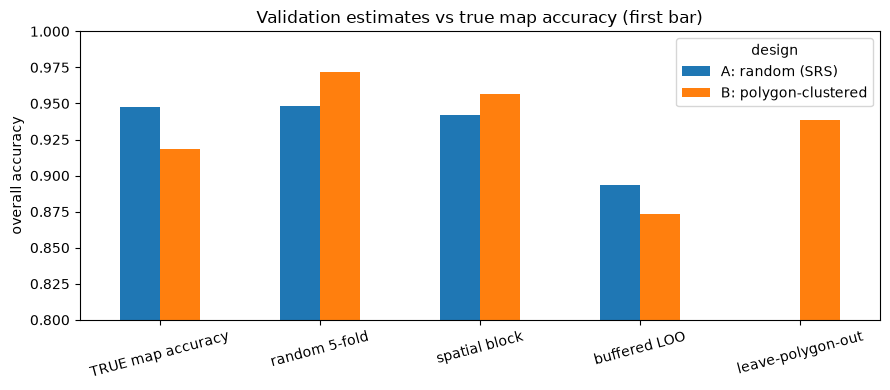

A: random (SRS): random CV overestimates the true map accuracy by +0.1 points; spatial block CV by -0.6 points
B: polygon-clustered: random CV overestimates the true map accuracy by +5.3 points; spatial block CV by +3.8 points


In [5]:
ax = cv_table.T.plot.bar(figsize=(9, 4), rot=15, ylim=(0.8, 1.0)); ax.set_ylabel("overall accuracy")
ax.set_title("Validation estimates vs true map accuracy (first bar)"); plt.tight_layout(); plt.show()
for d, r in cv_table.iterrows():
    print(f"{d}: random CV overestimates the true map accuracy by {100 * (r['random 5-fold'] - r['TRUE map accuracy']):+.1f} points; "
          f"spatial block CV by {100 * (r['spatial block'] - r['TRUE map accuracy']):+.1f} points")

Read the table carefully, because it holds both sides of a long debate in the literature:
- With **clustered** training data (Design B), random CV is optimistic: pixels of the same polygon sit in both training and test folds.
- The spatial strategies reduce that optimism, but by different amounts. Spatial blocks still leave some optimism, because a block border can cut through a cluster of polygons, so neighbouring polygons end up on both sides. The buffered LOO overshoots and becomes **pessimistic**: it predicts every test point from data farther away than most map pixels are from the nearest training polygon. **Leave-polygon-out** removes exactly the dependence that the sampling created, and nothing more, and lands closest to the truth.
- With a **random sample** (Design A), random CV is already close to the true accuracy, and buffered LOO is clearly pessimistic. Wadoux et al. (2021) make exactly this point: when the sample is a probability sample of the map, design-based (random) validation is unbiased.
- No CV can see the classes that were barely sampled (water and mining in Design B).

**Rule**: choose the CV that reproduces the *prediction situation*: how far, in space and feature space, the map pixels are from the training data. Section 5 measures that directly.

## **5. Is the CV Representative? Nearest-Neighbour Distance Distributions**
Milà et al. (2022) proposed comparing two distributions:
- **prediction-to-sample**: the distance from every map pixel to its nearest training sample (the prediction task)
- **CV test-to-train**: the distance from each CV test point to its nearest training point in that fold (what the CV evaluates)

A good CV makes the second distribution match the first. Their NNDM and kNNDM methods (Linnenbrink et al. 2024, R package `CAST`) build folds that do this automatically.

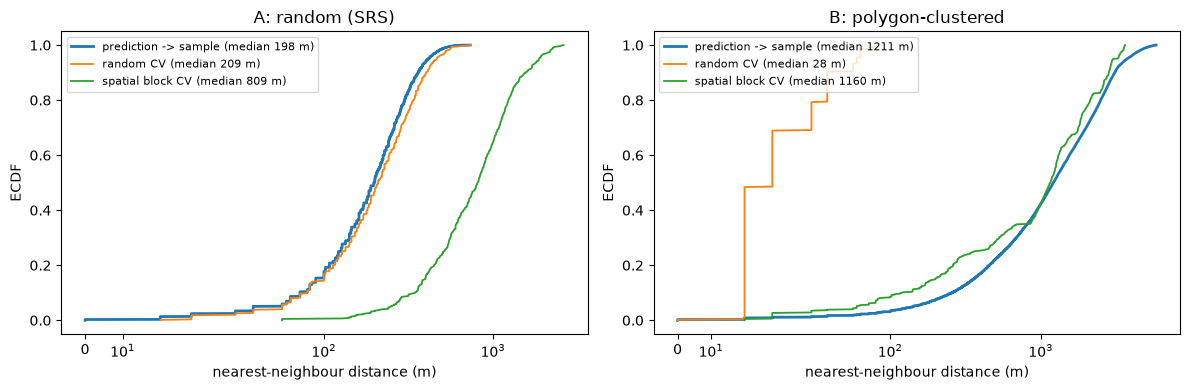

In [6]:
def nn_dist(a_xy, b_xy):
    return NearestNeighbors(n_neighbors=1).fit(b_xy).kneighbors(a_xy)[0][:, 0]

def cv_nn_distances(idx, splitter, groups=None):
    xy = np.c_[x_all[idx], yc_all[idx]]; out = []
    for tr, te in splitter.split(xy, groups=groups):
        out.append(nn_dist(xy[te], xy[tr]))
    return np.concatenate(out)

pred_pts = rng.choice(H * W, 20000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (d, idx) in zip(axes, designs.items()):
    xy = np.c_[x_all[idx], yc_all[idx]]
    curves = {"prediction -> sample": nn_dist(np.c_[x_all[pred_pts], yc_all[pred_pts]], xy),
              "random CV": cv_nn_distances(idx, KFold(5, shuffle=True, random_state=0)),
              "spatial block CV": cv_nn_distances(idx, GroupKFold(5), ru.spatial_blocks(xy[:, 0], xy[:, 1], BLOCK))}
    for lab, dd in curves.items():
        ax.plot(np.sort(dd), np.linspace(0, 1, len(dd)), lw=2 if "prediction" in lab else 1.3, label=f"{lab} (median {np.median(dd):.0f} m)")
    ax.set_xscale("symlog", linthresh=50); ax.set_xlabel("nearest-neighbour distance (m)"); ax.set_ylabel("ECDF"); ax.set_title(d); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

For Design B, random CV tests on points that are typically one pixel away from a training point, while map pixels are mostly hundreds of metres away. Spatial block CV shifts the test distances towards the prediction curve. How close it gets depends on the block size, which is why the estimate is so sensitive to it (Practice Problem 1). kNNDM folds are built to make the two curves match. For Design A the random-CV curve already matches the prediction curve, which explains Section 4.

### **Validation also changes model selection**
Optimistic CV does not only inflate the reported number. It can also pick the wrong model. A 1-nearest-neighbour classifier memorises training pixels, which is exactly what random CV on clustered data rewards.

In [7]:
knn1 = make_pipeline(StandardScaler(), KNeighborsClassifier(1))
blocks_B = ru.spatial_blocks(x_all[clu], yc_all[clu], BLOCK)
sel = []
for name, model in [("random forest", rf()), ("1-nearest neighbour", knn1)]:
    true_acc = accuracy_score(y_all, model.fit(X_all[clu], y_all[clu]).predict(X_all))
    sel.append({"model": name, "random CV": cv_accuracy(clu, model=model), "spatial block CV": cv_accuracy(clu, blocks_B, "block", model=model), "TRUE map accuracy": true_acc})
pd.DataFrame(sel).set_index("model").round(3)

,random CV,spatial block CV,TRUE map accuracy
model,,,
random forest,0.972,0.957,0.919
1-nearest neighbour,0.967,0.935,0.896


Random CV makes the memorising 1-NN classifier look almost as good as the random forest. Spatial CV exposes the real gap, which the true map accuracy confirms. So spatial CV shrinks the optimism of the estimate and also makes model comparisons fairer, even when it is a little pessimistic in absolute terms. Use it for **hyperparameter tuning and feature selection** too: put the spatial groups into `GridSearchCV(..., cv=GroupKFold(5))` and pass `groups=` to `fit` (Day 41), or use forward feature selection with spatial CV (Meyer et al. 2018). Coordinates and other location proxies often look great under random CV and hurt under spatial CV.

## **6. The Area of Applicability (AOA)**
A model can only be trusted where the predictors resemble the training data. Meyer & Pebesma (2021) define the **dissimilarity index (DI)**: the distance to the nearest training sample in the standardised, importance-weighted predictor space, divided by the mean distance between training samples. Pixels with DI above the largest DI seen inside cross-validation (an outlier-robust upper whisker) are **outside the AOA**. Report the AOA with the map, and mask or flag predictions outside it.

AOA threshold DI = 0.428; 84.8% of the map is inside the AOA
TRUE accuracy inside the AOA: 0.926 | outside: 0.878


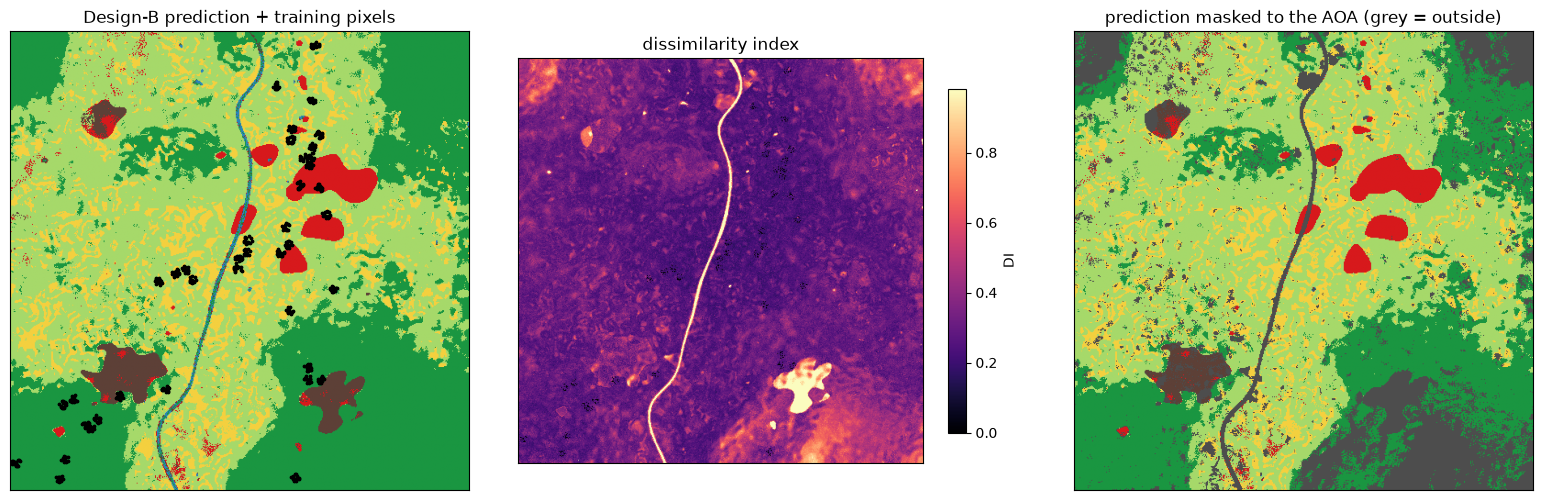

In [8]:
idx = clu
model_B = rf().fit(X_all[idx], y_all[idx])
folds = np.zeros(len(idx), int)
for f, (_, te) in enumerate(GroupKFold(5).split(idx, groups=poly_id)): folds[te] = f
di, thr = ru.dissimilarity_index(X_all[idx], X_all, weights=model_B.feature_importances_, cv_folds=folds)
inside = di <= thr; correct = maps["B: polygon-clustered"].ravel() == y_all
print(f"AOA threshold DI = {thr:.3f}; {inside.mean():.1%} of the map is inside the AOA")
print(f"TRUE accuracy inside the AOA: {correct[inside].mean():.3f} | outside: {correct[~inside].mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(maps["B: polygon-clustered"], cmap=cmap, norm=norm, extent=ext); axes[0].scatter(x_all[idx], yc_all[idx], c="k", s=3); axes[0].set_title("Design-B prediction + training pixels")
im = axes[1].imshow(di.reshape(H, W), cmap="magma", vmax=np.percentile(di, 99), extent=ext); fig.colorbar(im, ax=axes[1], shrink=0.75, label="DI"); axes[1].set_title("dissimilarity index")
axes[2].imshow(np.where(inside.reshape(H, W), maps["B: polygon-clustered"], np.nan), cmap=cmap, norm=norm, extent=ext); axes[2].set_facecolor("0.3")
axes[2].set_title("prediction masked to the AOA (grey = outside)")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Outside the AOA the model is clearly worse: there it extrapolates to spectra (water, mines, unusual hill slopes) it never saw. The AOA turns a hidden weakness into a map that readers can see. The fix is better sampling: put new samples where DI is high.

## **7. The Gold Standard: A Probability Sample and Stratified Estimators**
For the final accuracy and **area** numbers in a paper, follow the good-practice framework of Olofsson et al. (2014):
1. **Sampling design**: stratified random sampling with the **map classes as strata**, so that rare classes get enough samples.
2. **Response design**: how each sample unit's reference label is decided (very-high-resolution imagery, field visits, time series; several interpreters; label at the map's pixel size).
3. **Analysis**: estimate the error matrix in **area proportions** p_ij = W_i n_ij / n_i.+ (W_i = mapped area share of stratum i). From it come overall, user's and producer's accuracy and **bias-corrected class areas, each with 95% confidence intervals**.

Pixel counting ("the map says 1,234 ha of forest") is biased whenever omission and commission errors do not cancel. The stratified estimator corrects that.

### **Sample size (Olofsson et al. 2014, Eq. 13)**
n = (sum_i W_i S_i / S(O))^2, where S_i = sqrt(U_i (1 - U_i)) uses guessed user's accuracies U_i, and S(O) is the target standard error of overall accuracy.

In [9]:
map_A = maps["A: random (SRS)"]
counts = {k: int((map_A == k).sum()) for k in range(len(ru.LC_CLASSES))}
W_i = np.array([counts[k] for k in counts]) / (H * W)
U_guess = np.array([0.85, 0.9, 0.85, 0.8, 0.8, 0.9])                       # conjectured user's accuracies
target_se = 0.01
n_total = int(np.ceil((np.sum(W_i * np.sqrt(U_guess * (1 - U_guess))) / target_se) ** 2))
rare = W_i < 0.05
alloc = np.where(rare, 75, 0)                                                 # fixed 75 per rare class ...
alloc[~rare] = np.round((n_total - alloc.sum()) * W_i[~rare] / W_i[~rare].sum())   # ... rest proportional
alloc = {k: int(a) for k, a in enumerate(alloc)}
print(f"required n for SE(OA) = {target_se}: {n_total}")
pd.DataFrame({"class": ru.LC_CLASSES, "map share W_i": W_i.round(4), "allocated n": alloc.values()})

required n for SE(OA) = 0.01: 988


,class,map share W_i,allocated n
0,water,0.0090,75
1,forest,0.3291,268
2,cropland,0.1447,118
3,built_up,0.0244,75
4,mining_bare,0.0302,75
5,shrub_grass,0.4627,377


In [10]:
def validate(map_img, alloc, seed):
    r, c, strat = ru.stratified_random_sample(map_img, alloc, seed=seed)
    ref = truth[r, c]                                                         # reference labels (from interpretation in real life)
    return ru.olofsson_accuracy(strat, ref, counts, PIXEL_HA, ru.LC_CLASSES), strat, ref

(summary, pmat), strat, ref = validate(map_A, alloc, seed=10)
true_area = np.bincount(y_all, minlength=6) * PIXEL_HA
summary["TRUE_area_ha"] = true_area
print(f"OA (stratified estimator) = {summary.attrs['OA']:.3f} +/- {summary.attrs['OA_95CI']:.3f} | "
      f"naive sample OA = {np.mean(strat == ref):.3f} | TRUE map OA = {accuracy_score(y_all, map_A.ravel()):.3f}")
summary.round(3)

OA (stratified estimator) = 0.955 +/- 0.014 | naive sample OA = 0.960 | TRUE map OA = 0.948


,class,mapped_area_ha,sample_n,UA,UA_95CI,PA,PA_95CI,adjusted_area_ha,area_95CI_ha,TRUE_area_ha
0,water,89.52,75,1.000,0.000,1.000,0.000,89.520,0.000,91.44
1,forest,3290.76,268,0.978,0.018,0.932,0.028,3450.285,117.810,3432.40
2,cropland,1446.68,118,0.975,0.029,0.950,0.038,1483.547,71.726,1528.56
3,built_up,244.20,75,1.000,0.000,0.882,0.114,276.792,35.735,269.64
4,mining_bare,301.68,75,0.933,0.057,1.000,0.000,281.568,17.146,296.40
5,shrub_grass,4627.16,377,0.931,0.026,0.975,0.015,4418.287,137.050,4381.56


The **naive** sample OA (fraction of correct samples) is biased because rare classes were deliberately over-sampled. The stratified estimator re-weights by the mapped area of each stratum and lands close to the true accuracy.

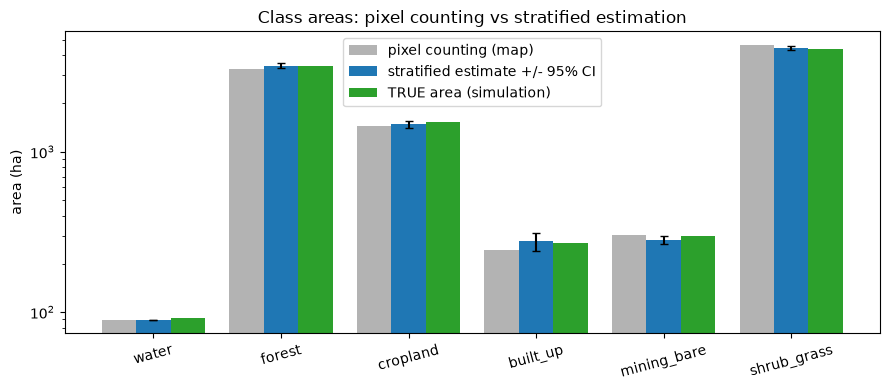

In [11]:
fig, ax = plt.subplots(figsize=(9, 4)); xk = np.arange(6); w = 0.27
ax.bar(xk - w, summary["mapped_area_ha"], w, label="pixel counting (map)", color="0.7")
ax.bar(xk, summary["adjusted_area_ha"], w, yerr=summary["area_95CI_ha"], capsize=3, label="stratified estimate +/- 95% CI", color="tab:blue")
ax.bar(xk + w, true_area, w, label="TRUE area (simulation)", color="tab:green")
ax.set_xticks(xk, ru.LC_CLASSES, rotation=15); ax.set_ylabel("area (ha)"); ax.set_yscale("log"); ax.legend(); ax.set_title("Class areas: pixel counting vs stratified estimation")
plt.tight_layout(); plt.show()

### **Quantity and allocation disagreement (instead of kappa)**
Kappa compares accuracy with a "random" baseline that has no meaning for maps, and it is not recommended (Pontius & Millones 2011; Foody 2020). Split the total disagreement 1 - OA into:
- **quantity disagreement**: wrong class *proportions* (matters for area statistics)
- **allocation disagreement**: right proportions in the wrong *places*

In [12]:
P = pmat.values
quantity = 0.5 * np.sum(np.abs(P.sum(1) - P.sum(0)))
total = 1 - np.trace(P); allocation = total - quantity
print(f"total disagreement {total:.3f} = quantity {quantity:.3f} + allocation {allocation:.3f}")
pmat.round(4)

total disagreement 0.045 = quantity 0.023 + allocation 0.022


,ref water,ref forest,ref cropland,ref built_up,ref mining_bare,ref shrub_grass
map water,0.009,0.0000,0.0000,0.0000,0.0000,0.0000
map forest,0.000,0.3217,0.0012,0.0000,0.0000,0.0061
map cropland,0.000,0.0000,0.1410,0.0000,0.0000,0.0037
map built_up,0.000,0.0000,0.0000,0.0244,0.0000,0.0000
map mining_bare,0.000,0.0000,0.0000,0.0008,0.0282,0.0012
map shrub_grass,0.000,0.0233,0.0061,0.0025,0.0000,0.4308


# **Part 2: Going Deeper**

## **8. Do the 95% Confidence Intervals Really Cover the Truth?**
A confidence interval is a promise about repeated sampling. In the simulation we can check that promise by drawing 300 independent validation samples and counting how often each interval contains the true value.

In [13]:
cover = {c: 0 for c in ru.LC_CLASSES}; cover_oa = 0; R = 300
true_oa = accuracy_score(y_all, map_A.ravel())
for s in range(R):
    (sm, _), _, _ = validate(map_A, alloc, seed=1000 + s)
    cover_oa += abs(sm.attrs["OA"] - true_oa) <= sm.attrs["OA_95CI"]
    for j, c in enumerate(ru.LC_CLASSES):
        cover[c] += abs(sm["adjusted_area_ha"].iloc[j] - true_area[j]) <= sm["area_95CI_ha"].iloc[j]
print(f"coverage of the 95% CI over {R} validation samples: OA {cover_oa / R:.1%}")
print({c: f"{v / R:.0%}" for c, v in cover.items()})

coverage of the 95% CI over 300 validation samples: OA 94.3%
{'water': '25%', 'forest': '96%', 'cropland': '93%', 'built_up': '87%', 'mining_bare': '93%', 'shrub_grass': '96%'}


Coverage close to 95% confirms that the estimator and its standard errors behave as promised. Low coverage for a class has two typical causes. First, very few samples land in the strata where its omission errors hide (a rare class omitted inside a large stratum). Second, the sample contains no errors at all for a class, so its estimated standard error is zero and the "interval" collapses to a single value, as for water here. The remedies are larger samples, better allocation, or extra strata such as a "buffer" stratum around the rare class (Olofsson et al. 2020).

## **9. Response Design and Other Sources of Error**
- **Reference label error**: interpreters disagree by 5-15% on mixed classes. Use several interpreters, record confidence, and report agreement.
- **Mixed pixels and geolocation**: label the whole pixel footprint (e.g. 20 m x 20 m) and record the majority class. A GPS error of 5-10 m at a boundary changes the label.
- **Temporal mismatch**: the reference imagery date must match the map date (land cover changes).
- **Spatial support**: validate at the scale of the map (pixel or MMU-filtered object), not at field-plot scale.

## **10. Reporting Checklist for a Remote-Sensing ML Paper**
1. Training data: source, sampling design, number of polygons and pixels per class, map of locations, label quality.
2. Spatial structure: variogram range or Moran's I of key predictors and residuals.
3. Model development: CV strategy, block size or buffer and why, tuning grid, feature selection, all done **inside** the spatial CV.
4. Final validation: an independent probability sample (design, strata, allocation, sample size calculation) with a documented response design.
5. Results: the error matrix in **area proportions**, OA, UA and PA **with 95% CIs**, bias-corrected areas with CIs, quantity and allocation disagreement. No kappa.
6. Area of applicability (or another extrapolation diagnostic) reported with the map.
7. Data and code availability (Day 99).

## **Practice Problems**
1. Repeat the Design-B spatial block CV with block sizes of 500 m, 1 km, 2 km and 4 km. How does the estimate change, and which is closest to the true accuracy?
2. Compute Moran's I of the **misclassification indicator** (1 = wrong) from the random CV of Design B. Are errors clustered in space?
3. Re-plan the validation for a target SE(OA) of 0.015 with 50 samples per rare class. How many samples do we need, and how much wider is the OA interval?
4. *(Advanced)* Validate the **Design-B map** with a stratified sample and the Olofsson estimator. Compare the estimate with Design B's random-CV accuracy and with the true map accuracy.

In [14]:
# Solution 1
for b in [500, 1000, 2000, 4000]:
    print(f"block {b:>4} m: spatial CV OA = {cv_accuracy(clu, ru.spatial_blocks(x_all[clu], yc_all[clu], b), 'block'):.3f}")
print(f"TRUE map accuracy (Design B): {cv_table.loc['B: polygon-clustered', 'TRUE map accuracy']:.3f}")

block  500 m: spatial CV OA = 0.950


block 1000 m: spatial CV OA = 0.925


block 2000 m: spatial CV OA = 0.942


block 4000 m: spatial CV OA = 0.807
TRUE map accuracy (Design B): 0.919


In [15]:
# Solution 2
pred_rand = cross_val_predict(rf(), X_all[clu], y_all[clu], cv=KFold(5, shuffle=True, random_state=0))
wrong = (pred_rand != y_all[clu]).astype(float)
print(f"misclassified: {wrong.mean():.3f}; Moran's I of errors = {ru.morans_i(wrong, x_all[clu], yc_all[clu]):.3f}")

misclassified: 0.028; Moran's I of errors = 0.160


In [16]:
# Solution 3
n3 = int(np.ceil((np.sum(W_i * np.sqrt(U_guess * (1 - U_guess))) / 0.015) ** 2))
a3 = np.where(rare, 50, 0); a3[~rare] = np.round((n3 - a3.sum()) * W_i[~rare] / W_i[~rare].sum()); a3 = {k: int(v) for k, v in enumerate(a3)}
(s3, _), _, _ = validate(map_A, a3, seed=10)
print(f"n = {n3} (vs {n_total}); OA = {s3.attrs['OA']:.3f} +/- {s3.attrs['OA_95CI']:.3f} (vs +/- {summary.attrs['OA_95CI']:.3f})")

n = 439 (vs 988); OA = 0.941 +/- 0.026 (vs +/- 0.014)


In [17]:
# Solution 4
map_B = maps["B: polygon-clustered"]
counts_B = {k: int((map_B == k).sum()) for k in range(6)}
alloc_B = {k: (75 if counts_B[k] / (H * W) < 0.05 else 200) for k in counts_B if counts_B[k] > 0}
rB, cB, sB = ru.stratified_random_sample(map_B, alloc_B, seed=3)
sumB, _ = ru.olofsson_accuracy(sB, truth[rB, cB], {k: v for k, v in counts_B.items() if v > 0}, PIXEL_HA,
                               [ru.LC_CLASSES[k] for k in counts_B if counts_B[k] > 0])
print(f"Design-B map | stratified estimate OA = {sumB.attrs['OA']:.3f} +/- {sumB.attrs['OA_95CI']:.3f} | "
      f"random CV {cv_table.loc['B: polygon-clustered', 'random 5-fold']:.3f} | TRUE {accuracy_score(y_all, map_B.ravel()):.3f}")

Design-B map | stratified estimate OA = 0.925 +/- 0.023 | random CV 0.972 | TRUE 0.919


## **Key References**
- Olofsson, P., Foody, G. M., Herold, M., Stehman, S. V., Woodcock, C. E., & Wulder, M. A. (2014). Good practices for estimating area and assessing accuracy of land change. *Remote Sensing of Environment*, 148, 42-57.
- Stehman, S. V., & Foody, G. M. (2019). Key issues in rigorous accuracy assessment of land cover products. *Remote Sensing of Environment*, 231, 111199.
- Meyer, H., & Pebesma, E. (2021). Predicting into unknown space? Estimating the area of applicability of spatial prediction models. *Methods in Ecology and Evolution*, 12(9), 1620-1633.
- Meyer, H., Reudenbach, C., Hengl, T., Katurji, M., & Nauss, T. (2018). Improving performance of spatio-temporal machine learning models using forward feature selection and target-oriented validation. *Environmental Modelling & Software*, 101, 1-9.
- Ploton, P. et al. (2020). Spatial validation reveals poor predictive performance of large-scale ecological mapping models. *Nature Communications*, 11, 4540.
- Wadoux, A. M. J.-C., Heuvelink, G. B. M., de Bruin, S., & Brus, D. J. (2021). Spatial cross-validation is not the right way to evaluate map accuracy. *Ecological Modelling*, 457, 109692.
- Milà, C., Mateu, J., Pebesma, E., & Meyer, H. (2022). Nearest neighbour distance matching leave-one-out cross-validation for map validation. *Methods in Ecology and Evolution*, 13(6), 1304-1316.
- Linnenbrink, J., Milà, C., Ludwig, M., & Meyer, H. (2024). kNNDM CV: k-fold nearest-neighbour distance matching cross-validation for map accuracy estimation. *Geoscientific Model Development*, 17, 5897-5912.
- Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40(8), 913-929.
- Valavi, R., Elith, J., Lahoz-Monfort, J. J., & Guillera-Arroita, G. (2019). blockCV: An R package for generating spatially or environmentally separated folds for k-fold cross-validation of species distribution models. *Methods in Ecology and Evolution*, 10(2), 225-232.
- Pontius, R. G., & Millones, M. (2011). Death to Kappa: birth of quantity disagreement and allocation disagreement for accuracy assessment. *International Journal of Remote Sensing*, 32(15), 4407-4429.
- Foody, G. M. (2020). Explaining the unsuitability of the kappa coefficient in the assessment and comparison of the accuracy of thematic maps obtained by image classification. *Remote Sensing of Environment*, 239, 111630.